In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.rc('text', usetex = True)

from ast import literal_eval as liteval 
import numpy as np
import os
import math as m
import scipy.optimize as sciopt

import sys
sys.path.insert(0, os.getcwd().removesuffix("/psps"))
sys.path.insert(0, os.getcwd().removesuffix("/ashwin_md/ld_analysis/log/psps") + "/code/py/Math")
import file_utils
from file_utils import readData, float2latex
from fitdat import theil_sen, ax_pow_b
sys.path.pop(0)

dirpath = "//media/ashwin/ASH_DRIVE_3/ashwin_md/psps"
figpath = "/home/ashwin/Desktop/ashwin_md/LD/imgs/Nov2025/"

colors = ["darkorange", "crimson", "#2544D0", "olive", "orangered", "#2544D0", "k"]

Collision Statistics:

     (Fd=20)      Max Min Avg RMS

Collision time :  7.8 0.3 1.0712 1.2004
x-displacemnets:  4.6035 0.0015 0.6488 0.776
y-displacements:  4.0116 0.0009 0.584 0.6747

     (Fd=40)      Max Min Avg RMS

Collision time :  2.4 0.2 0.5956 0.6513
x-displacemnets:  3.247 0.001 0.5409 0.6501
y-displacements:  1.9338 0.0009 0.4765 0.5412

     (Fd=60)      Max Min Avg RMS

Collision time :  1.65 0.15 0.4227 0.4567
x-displacemnets:  3.189 0.0005 0.5372 0.6449
y-displacements:  1.86 0.0017 0.4558 0.5151

     (Fd=80)      Max Min Avg RMS

Collision time :  1.3 0.13 0.3419 0.3683
x-displacemnets:  3.332 0.0 0.5763 0.6947
y-displacements:  1.8073 0.0039 0.4445 0.502

     (Fd=100)      Max Min Avg RMS

Collision time :  1.1 0.11 0.2873 0.3101
x-displacemnets:  3.742 0.0 0.6303 0.7593
y-displacements:  1.5203 0.0027 0.4507 0.5081

     (Fd=150)      Max Min Avg RMS

Collision time :  0.99 0.09 0.2199 0.2374
x-displacemnets:  5.679 0.0 0.8284 0.9873
y-displacements:  1.8425 0.0

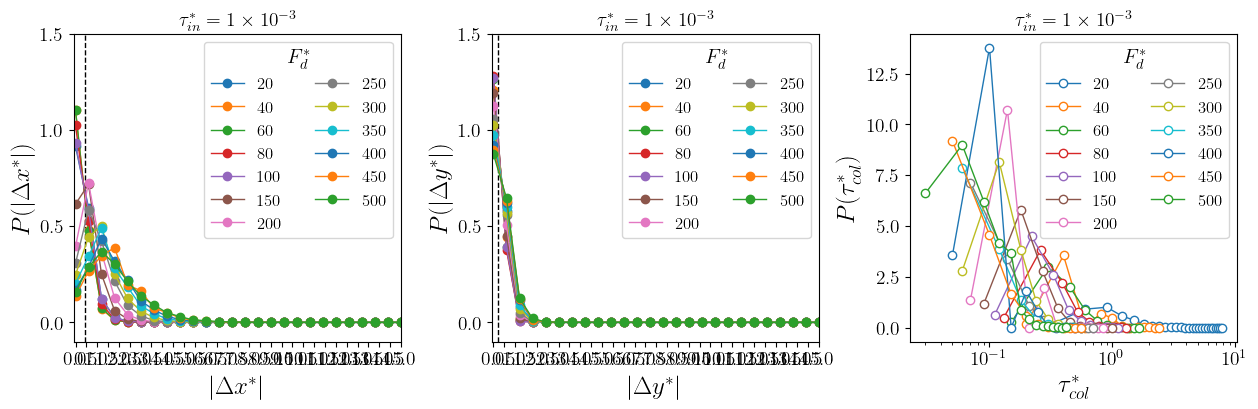

In [16]:
# Plot of collisions time and displacement distributions obtained from collisions.cpp 

dt = 5e-4
tau_in = "1e-1"
Fd_list = ["20", "40", "60", "80", "100", "150", "200", "250", "300", "350", "400", "450", "500"]
frameW = [600, 400, 300, 260, 220, 180, 140, 135, 120, 110, 100, 95, 50]

file_paths = []
for i in range(len(Fd_list)):
    file_paths.append(os.path.join(dirpath, "tau_{Tau}".format(Tau = tau_in), "Fd{fd}".format(fd = Fd_list[i]), "collisions.dat"))

max_x = 15
nBins = 25
binW_x = round(max_x/nBins, 2)
nBins_x = m.floor(max_x/binW_x) + 1

binW_tau = [(round(i*dt, 2)) for i in frameW]

ms = 6
lw = 1

fig, ax = plt.subplots(1, 3, figsize = (15, 4))
ax[0].axvline(x = 0.425, ymin = 0, ymax = 1, linestyle = "--", color = "k", lw = lw)
ax[1].axvline(x = 0.20, ymin = 0, ymax = 1, linestyle = "--", color = "k", lw = lw)

print("Collision Statistics:")
max_prob_x = 0
max_prob_tau = 0
for i in range(len(file_paths)):
    [data, _] = readData(file_paths[i], 1)

    tau_col = data[1]
    delx = data[2]
    dely = data[3]

    avg_tau_col = round(sum(tau_col)/len(tau_col), 4)
    avg_delx = round(sum(delx)/len(delx), 4)
    avg_dely = round(sum(dely)/len(dely), 4)

    rms_tau_col = round(m.sqrt(sum([tau**2 for tau in tau_col])/len(tau_col)), 4)
    rms_delx = round(m.sqrt(sum([dx**2 for dx in delx])/len(delx)), 4)
    rms_dely = round(m.sqrt(sum([dy**2 for dy in dely])/len(dely)), 4)

    print("\n     (Fd={fd})      Max Min Avg RMS\n".format(fd = Fd_list[i]))
    print("Collision time : ", round(max(tau_col), 4), round(min(tau_col), 4), avg_tau_col, rms_tau_col)
    print("x-displacemnets: ", round(max(delx), 4), round(min(delx), 4), avg_delx, rms_delx)
    print("y-displacements: ", round(max(dely), 4), round(min(dely), 4), avg_dely, rms_dely)

    bin_delx = np.zeros(nBins_x)
    bin_dely = np.zeros(nBins_x)
    x = [(j*binW_x) for j in range(nBins_x)]

    max_tau = round(max(tau_col), 4)
    nBins_tau = int(round(max_tau/ binW_tau[i])) + 1
    
    bin_tau_col = np.zeros(nBins_tau)
    tau = [(j*binW_tau[i]) for j in range(nBins_tau)]
    
    for j in range(len(delx)):
        bin_delx[int(delx[j]/binW_x)] += 1
        bin_dely[int(dely[j]/binW_x)] += 1
        bin_tau_col[int(tau_col[j]/binW_tau[i])] += 1
    
    for j in range(len(bin_delx)):
        bin_delx[j] /= (len(delx) * binW_x)
        bin_dely[j] /= (len(delx) * binW_x)

    for j in range(len(bin_tau_col)):
        bin_tau_col[j] /= (len(tau_col) * binW_tau[i])

    if(max_prob_x < max(bin_delx)): max_prob_x = max(bin_delx)
    if(max_prob_x < max(bin_dely)): max_prob_x = max(bin_dely)
    if(max_prob_tau < max(bin_tau_col)): max_prob_tau = max(bin_tau_col)

    ax[0].plot(x, bin_delx, "o-", ms = ms, lw = lw, label = r"${Fd}$".format(Fd = Fd_list[i]))
    ax[1].plot(x, bin_dely, "o-", ms = ms, lw = lw, label = r"${Fd}$".format(Fd = Fd_list[i]))
    
    line, = ax[2].semilogx(tau[1::], bin_tau_col[1::], "o-", ms = ms, lw = lw, fillstyle = "full", mfc = "white", 
                   label = r"${Fd}$".format(Fd = Fd_list[i]))
    l_color = line.get_color()
    
ax[0].set_xlabel(r"$|\Delta x^*|$", fontsize = 18)
ax[0].set_ylabel(r"$P(|\Delta x^*|)$", fontsize = 18)
ax[0].set(xlim = (-0.05, max_x))
ax[0].set_ylim(bottom = -0.1)
ax[0].set_xticks(np.arange(0, max_x + 0.4, 0.5))
ax[0].set_yticks(np.arange(0, max_prob_x + 0.5, 0.5))
ax[0].tick_params(axis = "both", which = "major", labelsize = 14)
ax[0].set_title(r"$\tau_{in}^* = 1\times 10^{-3}$", fontsize = 14)
leg = ax[0].legend(title = r"$F_d^*$", ncols = 2, fontsize = 12)
leg.get_title().set_fontsize("15")

ax[1].set_xlabel(r"$|\Delta y^*|$", fontsize = 18)
ax[1].set_ylabel(r"$P(|\Delta y^*|)$", fontsize = 18)
ax[1].set(xlim = (-0.05, max_x))
ax[1].set_ylim(bottom = -0.1)
ax[1].set_xticks(np.arange(0, max_x + 0.4, 0.5))
ax[1].set_yticks(np.arange(0, max_prob_x + 0.5, 0.5))
ax[1].tick_params(axis = "both", which = "major", labelsize = 14)
ax[1].set_title(r"$\tau_{in}^* = 1\times 10^{-3}$", fontsize = 14)
leg = ax[1].legend(title = r"$F_d^*$", ncols = 2, fontsize = 12)
leg.get_title().set_fontsize("15")

ax[2].set_xlabel(r"$\tau_{col}^*$", fontsize = 18)
ax[2].set_ylabel(r"$P(\tau_{col}^*)$", fontsize = 18)
# ax[2].set_xlim(0, 500)
# ax[2].set_xticks(np.arange(0, 500, 100))
# ax[2].set_yticks(np.arange(0, max_prob_tau, 0.004))
ax[2].tick_params(axis = "both", which = "major", labelsize = 14)
ax[2].set_title(r"$\tau_{in}^* = 1\times10^{-3}$", fontsize = 14)
leg = ax[2].legend(title = r"$F_d^*$", ncols = 2, fontsize = 12)
leg.get_title().set_fontsize("15")

plt.subplots_adjust(wspace = 0.28)

# fig.savefig(os.path.join(figpath, "collisions_tau_1e-3.png"), dpi = 1200, bbox_inches = "tight")

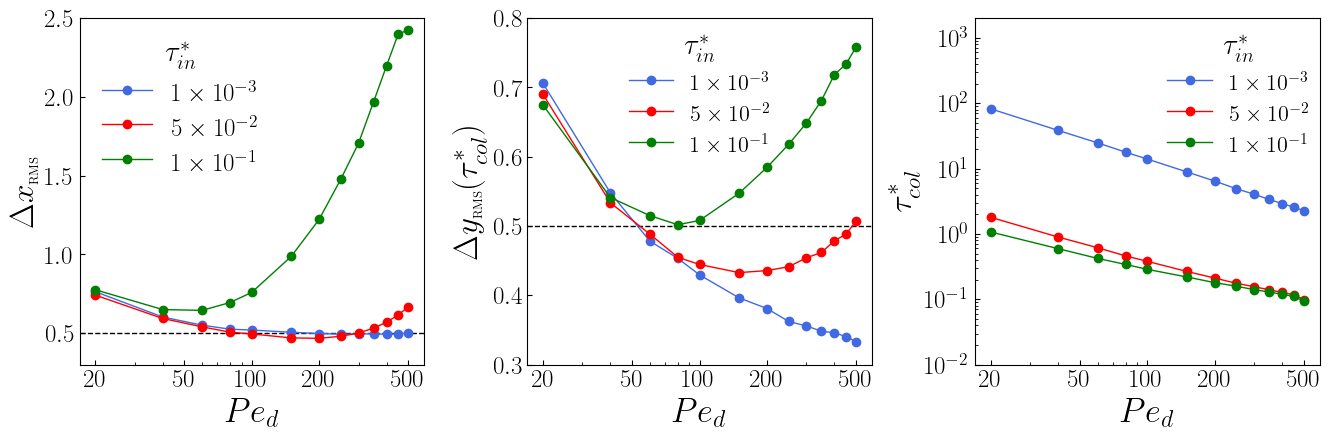

In [24]:
# Plot of mean displacements and collisional times as a function of driving force

tau_list = ["1e-3", "5e-2", "1e-1"]
colors = ["royalblue", "r", "g"]
markers = ["o", "s", "^"]

fig, ax = plt.subplots(1, 3, figsize = (16, 4.5))

ms = 6
lw = 1

ax[0].axhline(y = 0.5, xmin = 0, xmax = 1, linestyle = "--", color = "k", lw = lw)
ax[1].axhline(y = 0.5, xmin = 0, xmax = 1, linestyle = "--", color = "k", lw = lw)

lines = []
points = []
for i in range(len(tau_list)):
    fpath = os.path.join(dirpath, "tau_{Tau}".format(Tau = tau_list[i]), "collision_stats.dat")
    [data, _] = readData(fpath, 1)
    
    Fd = data[0]
    tau_col_th = data[1]
    tau_col_avg = data[2]
    delx_rms = data[3]
    dely_rms = data[4]
    
    ax[0].semilogx(Fd, delx_rms, "o-", color = colors[i], ms = ms, lw = lw,
                   label = r"${tau}$".format(tau = float2latex([tau_list[i]])))
    
    ax[1].semilogx(Fd, dely_rms, "o-", color = colors[i], ms = ms, lw = lw, 
                   label = r"${tau}$".format(tau = float2latex([tau_list[i]])))
    
    line, = ax[2].loglog(Fd, tau_col_avg, "o-", color = colors[i], ms = ms, lw = lw,
                         label = r"${tau}$".format(tau = float2latex([tau_list[i]])))
    # point, = ax[2].loglog(Fd, tau_col_th, "--o", ms = ms, lw = lw, color = colors[i], fillstyle = "full", mfc = "white", mew = 1.5, 
    #                       label = r"${tau}$".format(tau = float2latex([tau_list[i]])))

    lines.append(line)
    points.append(point)

ax[0].set_xlabel(r"$Pe_d$", fontsize = 25)
ax[0].set_ylabel(r"$\Delta x_{\textrm{\small RMS}}$", fontsize = 24)
ax[0].set_ylim(0.3, 2.5)
ax[0].set_xticks([20, 50, 100, 200, 500])
ax[0].set_xticklabels([r"${i}$".format(i = fd) for fd in [20, 50, 100, 200, 500]])
ax[0].tick_params(axis = "both", which = "major", labelsize = 18)
ax[0].tick_params(axis = "both", which = "both", direction = "in")
leg = ax[0].legend(title = r"$\tau_{in}^*$", frameon = False, fontsize = 18)
leg.get_title().set_fontsize("21")

ax[1].set_xlabel(r"$Pe_d$", fontsize = 25)
ax[1].set_ylabel(r"$\Delta y_{\textrm{\small RMS}}(\tau_{col}^*)$", fontsize = 24)
ax[1].set_ylim(0.3, 0.8)
ax[1].set_xticks([20, 50, 100, 200, 500])
ax[1].set_xticklabels([r"${i}$".format(i = fd) for fd in [20, 50, 100, 200, 500]])
ax[1].tick_params(axis = "both", which = "major", labelsize = 18)
ax[1].tick_params(axis = "both", which = "both", direction = "in")
leg = ax[1].legend(title = r"$\tau_{in}^*$", frameon = False, fontsize = 16, bbox_to_anchor = (0.5, 0.55))
leg.get_title().set_fontsize("21")

ax[2].set_xlabel(r"$Pe_d$", fontsize = 25)
ax[2].set_ylabel(r"$\tau_{col}^*$", fontsize = 24)
ax[2].set_ylim((1e-2, 2e3))
ax[2].set_xticks([20, 50, 100, 200, 500])
ax[2].set_xticklabels([r"${i}$".format(i = fd) for fd in [20, 50, 100, 200, 500]])
# ax[2].set_yticks(np.arange(1e-, 90, 20))
ax[2].tick_params(axis = "both", which = "major", labelsize = 18)
ax[2].tick_params(axis = "both", which = "both", direction = "in")
# leg = plt.legend(handles = points, title = "MSD theory", fontsize = 12, bbox_to_anchor = (0.62, 1))
# leg.get_title().set_fontsize("13")
leg2 = ax[2].legend(handles = lines, title = r"$\tau_{in}^*$", fontsize = 16, bbox_to_anchor = (0.5, 0.55), frameon = False)
leg2.get_title().set_fontsize("21")
# ax[2].add_artist(leg)

plt.subplots_adjust(wspace = 0.3)

# fig.savefig(os.path.join(figpath, "rms_displacements.png"), dpi = 900, bbox_inches = "tight")

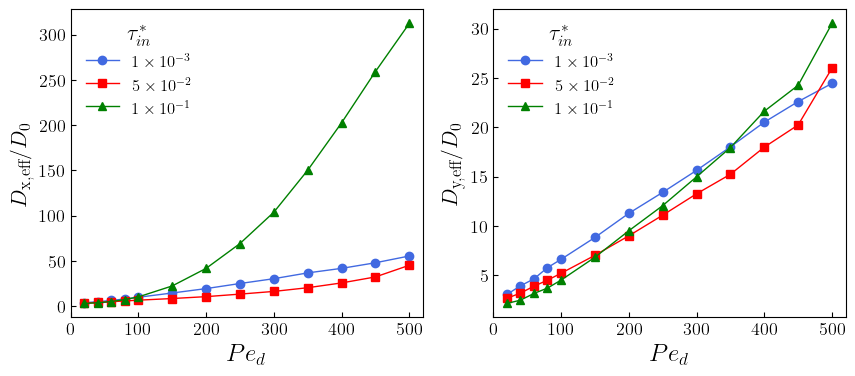

In [4]:
fig2, ax2 = plt.subplots(1, 2, figsize = (10, 4))

for i in range(len(tau_list)):
    fpath = os.path.join(dirpath, "tau_{Tau}".format(Tau = tau_list[i]), "collision_stats.dat")
    [data, _] = readData(fpath, 1)
    
    Fd = data[0]
    tau_col_th = data[1]
    tau_col_avg = data[2]
    delx_rms = data[3]
    dely_rms = data[4]

    norm = liteval(tau_list[i])
    # norm = 1
    Deff_x = [(delx_rms[i]**2/(2*norm*tau_col_avg[i])) for i in range(len(tau_col_avg))]
    Deff_y = [(dely_rms[i]**2/(2*norm*tau_col_avg[i])) for i in range(len(tau_col_avg))]
    
    ax2[0].plot(Fd, Deff_x, ls = "-", marker = markers[i], ms = ms, lw = lw, color = colors[i], 
                label = r"${tau}$".format(tau = float2latex([tau_list[i]])))
    
    ax2[1].plot(Fd, Deff_y, ls = "-", marker = markers[i], ms = ms, lw = lw, color = colors[i], 
                label = r"${tau}$".format(tau = float2latex([tau_list[i]])))

ax2[0].set_xlabel(r"$Pe_d$", fontsize = 18)
ax2[0].set_ylabel(r"$D_{\textrm{\large x,eff}}/D_0$", fontsize = 16)
ax2[0].tick_params(axis = "both", which = "major", direction = "in", labelsize = 13)
ax2[0].set_xlim(0, 520)
leg = ax2[0].legend(title = r"$\tau_{in}^*$", frameon = False, fontsize = 12)
leg.get_title().set_fontsize("16")

ax2[1].set_xlabel(r"$Pe_d$", fontsize = 18)
ax2[1].set_ylabel(r"$D_{\textrm{\large y,eff}}/D_0$", fontsize = 16)
ax2[1].tick_params(axis = "both", which = "major", direction = "in", labelsize = 13)
ax2[1].set_xlim(0, 520)
leg = ax2[1].legend(title = r"$\tau_{in}^*$", frameon = False, fontsize = 12)
leg.get_title().set_fontsize("16")

# fig2.savefig(os.path.join(figpath, "Deff.png"), dpi = 900, bbox_inches = "tight")

In [21]:
Fd_max = 500
def return_color(x):
    cmap1 = mpl.colormaps['plasma']
    return(cmap1(x/Fd_max))

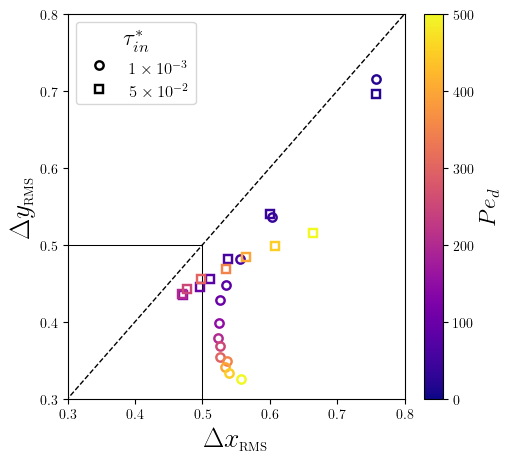

In [25]:
marker = ["o", "s"]

fig3, ax3 = plt.subplots(figsize = (5, 5))

ax3.plot(np.arange(0.2, 1.05, 0.05), np.arange(0.2, 1.05, 0.05), "k--", lw = lw)
ax3.axhline(y = 0.5, xmin = 0, xmax = 0.4, linestyle = "-", color = "k", lw = 0.75)
ax3.axvline(x = 0.5, ymin = 0, ymax = 0.4, linestyle = "-", color = "k", lw = 0.75)

for i in range(len(tau_list)):
    fpath = os.path.join(dirpath, "tau_{Tau}".format(Tau = tau_list[i]), "collision_stats.dat")
    [data, _] = readData(fpath, 1)
    
    Fd = data[2]
    tau_col_th = data[3]
    tau_col_avg = data[4]
    delx_avg = data[5]
    dely_avg = data[6]
    delx_rms = data[7]
    dely_rms = data[8]

    for j in range(len(Fd)):
        ax3.plot(delx_rms[j], dely_rms[j], marker[i], color = return_color(Fd[j]), ms = 6, fillstyle = "none", mew = 1.75)
    ax3.plot(0, 0, marker = marker[i], color = "k", ms = ms, lw = 0, fillstyle = "none", mew = 1.75,
             label = r"${Tau}$".format(Tau = float2latex([tau_list[i]])))

ax3.set(xlim = (0.3, 0.8), ylim = (0.3, 0.8))
ax3.set_xlabel(r"$\Delta x_{\textrm{\small RMS}}$", fontsize = 20)
ax3.set_ylabel(r"$\Delta y_{\textrm{\small RMS}}$", fontsize = 20)

leg = ax3.legend(title = r"$\tau_{in}^*$", fontsize = 12)
leg.get_title().set_fontsize("17")

cmap1 = mpl.colormaps['plasma']
clb = mpl.cm.ScalarMappable(norm = mpl.colors.Normalize(0, 500, 50), cmap = cmap1)
cbar = fig3.colorbar(clb, ax = ax3, location = "right", shrink = 1.0, aspect = 20, pad = 0.05, fraction = 0.08,
                   ticks = np.arange(0, 550, 100))
cbar.set_label(r"$Pe_d$", fontsize = 17)

# fig3.savefig(os.path.join(figpath, "scatter_displacements.png"), dpi = 600, bbox_inches = "tight")